### Imports

In [27]:
# Adjust import path
import sys
sys.path.append("../ODEs")
sys.path.append("../")

In [28]:
# Imports
import os
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt

import opinf

import utils
import config_lotka_volterra as config
import step1_generate_data as step1
import step1_5_estimate_priors as step1_5
import step2_fitgps as step2
import step3_estimate as step3
import step4_plot as step4
import torch
import numpy as np
import random

seed = 21092023  # Or any integer you prefer

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
%load_ext autoreload
%autoreload 2
import importlib
import sys

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Create Data

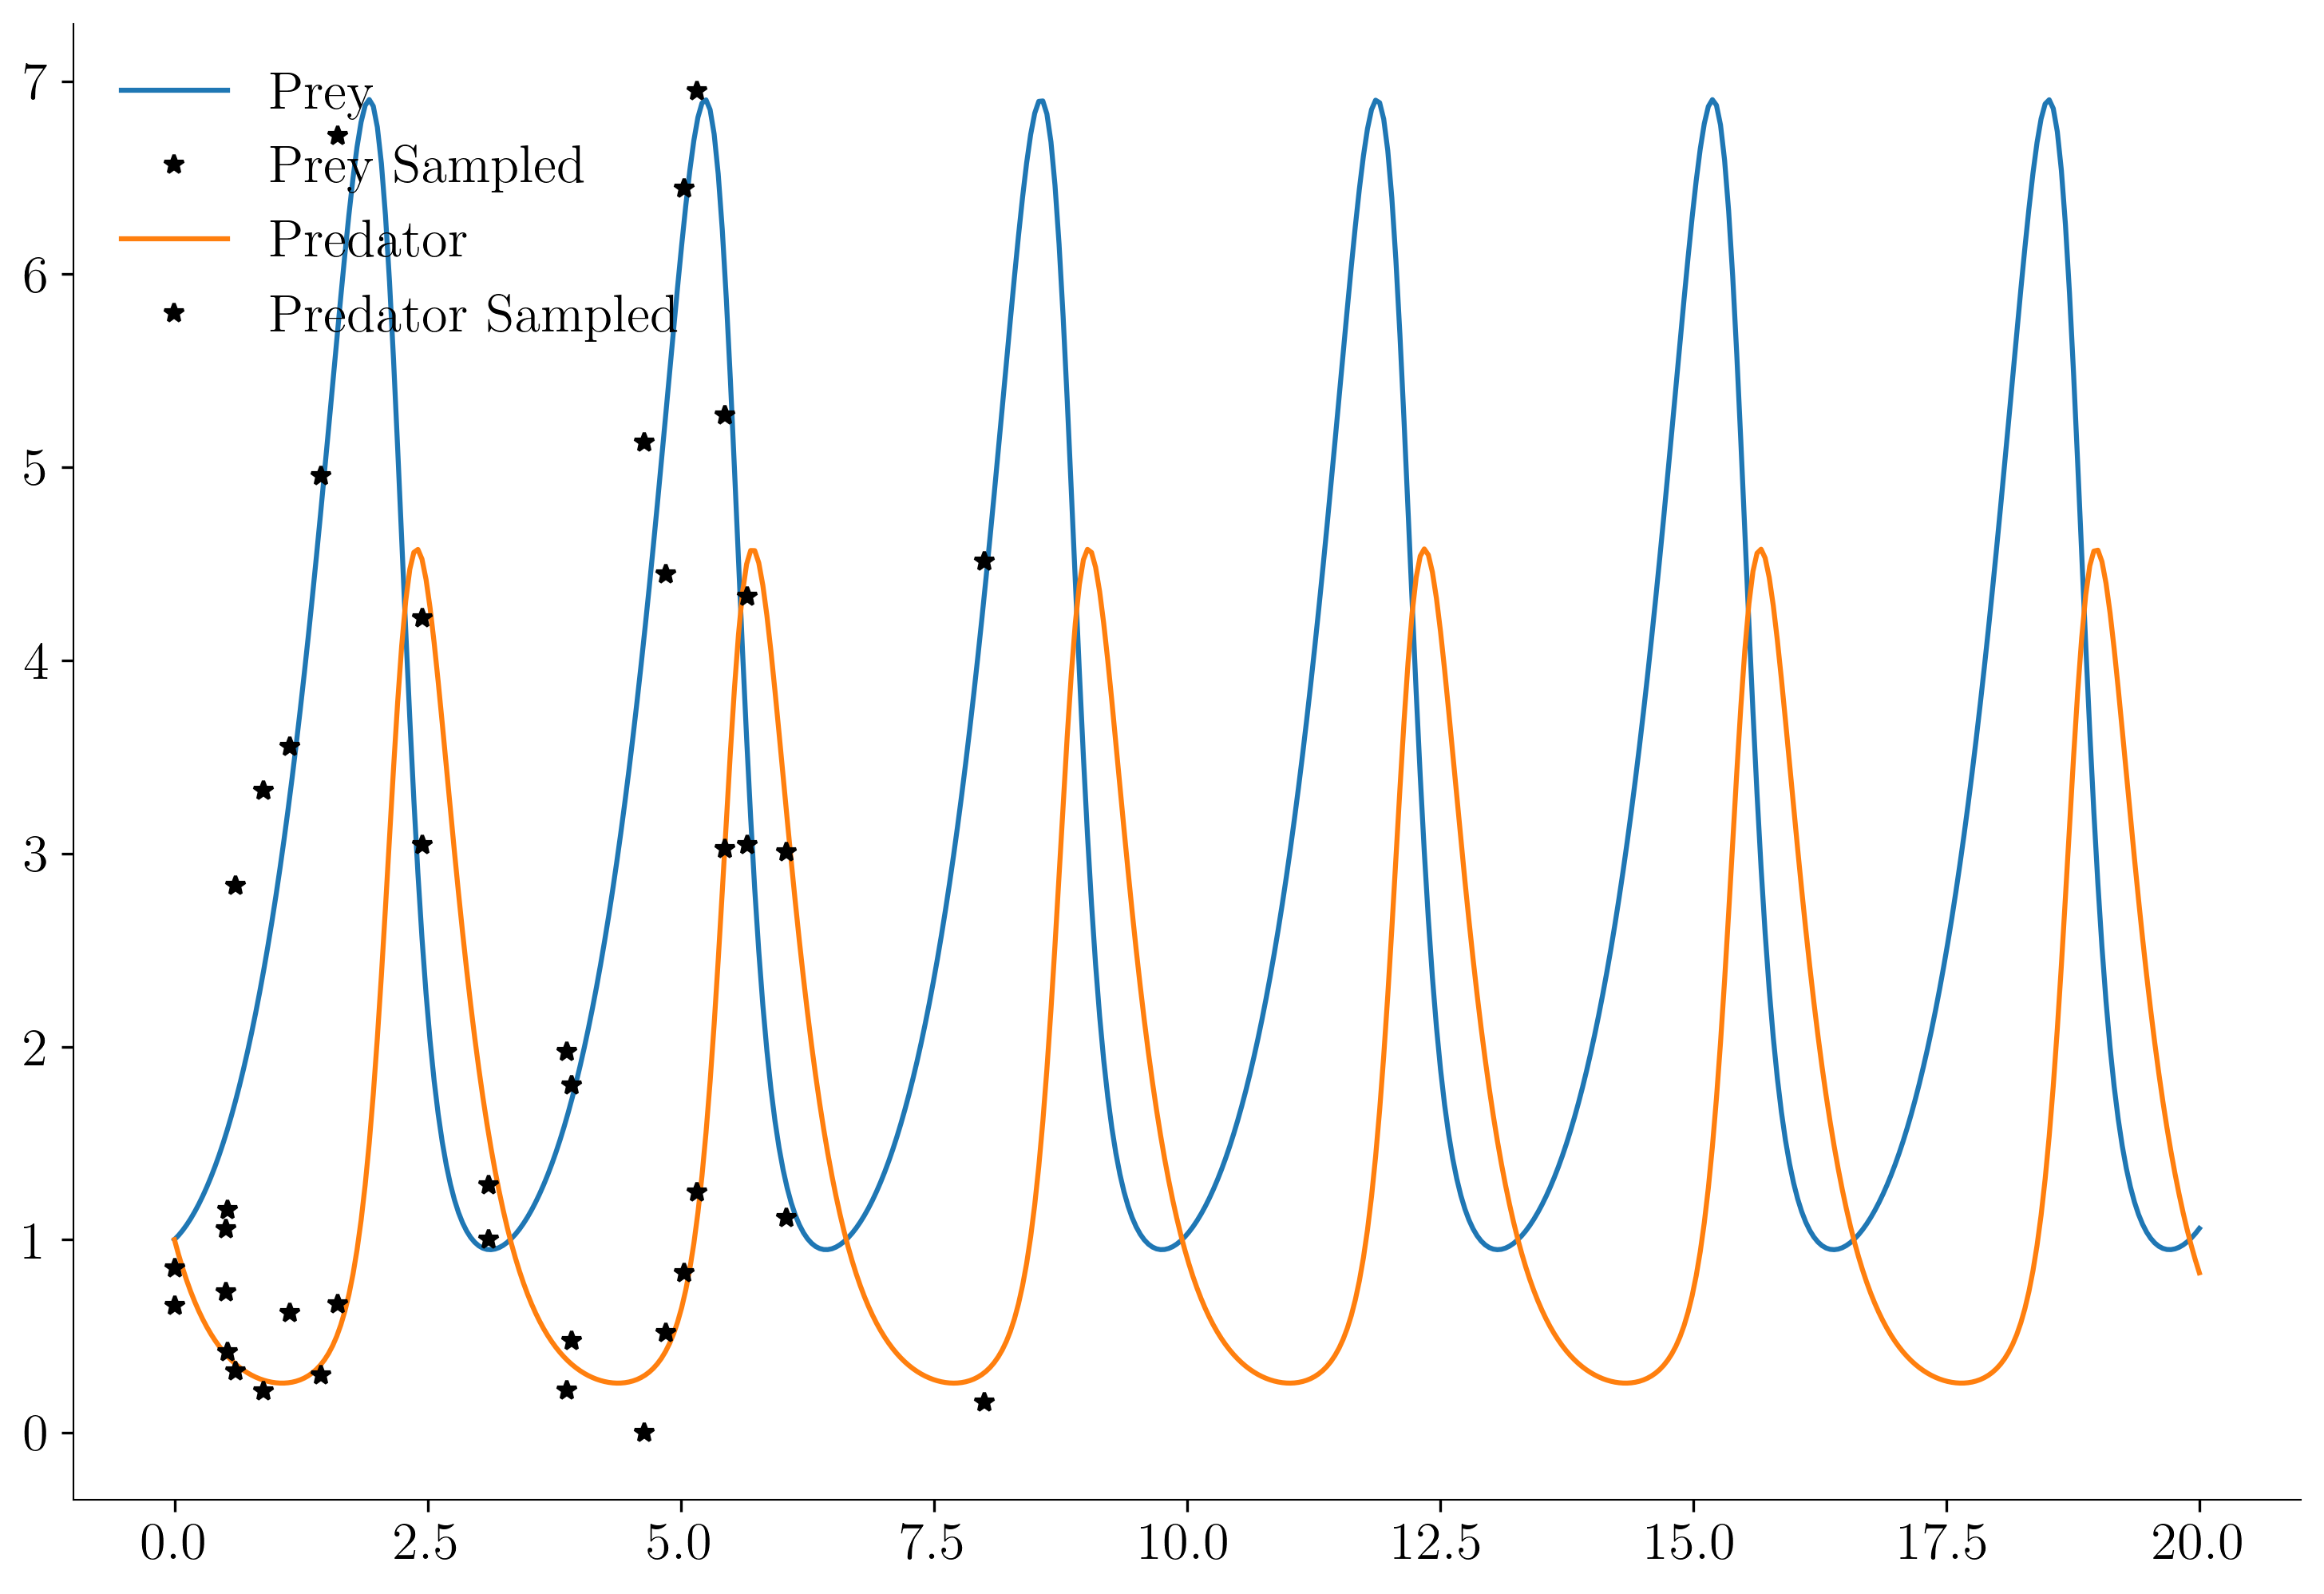

In [29]:
training_span = (0,8)
num_samples = 20
noiselevel = .2
num_regression_points = 300
# Step 1: Generate data ---------------------------------------------------
config.alpha, config.beta, config.gamma, config.delta = 1.5, 1, 3, 1
sampler = step1.TrajectorySampler(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    synced=True,
    integersonly=False,
    config=config,
)

(
    truthmodel,
    time_domain_prediction,
    true_states,
    time_domains_sampled,
    snapshots_sampled,
) = sampler.sample()
true_parameters = np.copy(truthmodel.parameters)

num_vars = len(true_states)
for i in range(num_vars):
    plt.plot(time_domain_prediction, true_states[i], label='Prey' if i == 0 else 'Predator')
    plt.plot(time_domains_sampled[i], snapshots_sampled[i], 'k*', label='Prey Sampled' if i == 0 else 'Predator Sampled')
plt.legend()
plt.show()

### Train GPS

In [30]:
import numpy as np
from RBF import RBF
import os

from matplotlib import pyplot as plt

# decide if the data should be standardized in a preprocessing step
standardize = True

"""kernel optimization"""
# amount of basinhopping iterations in kernel hyperparameter optimization
kernelIter = 100  # should be adjusted based on roughness of likelihood
optimizer = 'basinhopping'
gammaValue = 3e-1
gammaValues = np.asarray(gammaValue).reshape([-1, 1])

y = np.array(snapshots_sampled).transpose(1,0)
time = np.array(time_domains_sampled)[0]
print(time.shape)

"""create Kernel and Kernel matrices"""
kernel = RBF(theta=np.abs(np.random.randn(2)),
             sigma=np.abs(np.random.randn(1)))
kernel.learnHyperparams(
    kernel.theta,
    kernel.sigma,
    y,
    time,
    normalize=True,
    standardize=standardize,
    newNugget=1e-4,
    anneal=False,
    basinIter=kernelIter,
    optimizer=optimizer
    )

(20,)
[(0.0001, np.float64(48.287231045547074)), (np.float64(0.5050484674059952), np.float64(50.50484674059952)), (0.001, np.float64(6.948901427243523))]
[(0.0001, np.float64(48.287231045547074)), (np.float64(0.5050484674059952), np.float64(50.50484674059952)), (0.001, np.float64(6.948901427243523))]
using L-BFGS-B as hyperparameter optimizer with basin hopping
YES: 0.40954553402670957 @ [1.13046294 0.50504847 0.29435   ]
Nope: 2.000198932879237 @ [1.00000000e-04 5.05048467e+01 9.99999470e-01]
Nope: 2.000198174705294 @ [1.00000000e-04 3.67497330e+01 9.99998135e-01]
Nope: 2.0001819042638305 @ [1.00000000e-04 1.07572923e+01 9.99990942e-01]
Nope: 2.0001988415467866 @ [1.00000000e-04 4.80056400e+01 9.99999411e-01]
YES: 2.0001957968768362 @ [1.00000000e-04 2.32882157e+01 9.99997896e-01]
YES: 2.000198932879239 @ [1.00000000e-04 5.05048467e+01 9.99999483e-01]
YES: 2.000198221325439 @ [1.00000000e-04 3.72944607e+01 9.99999101e-01]
YES: 2.0001985703202276 @ [1.00000000e-04 4.23165872e+01 9.9999

In [31]:
theta = np.asarray(kernel.theta)
sigma = np.asarray(kernel.sigma).reshape([1,1])
print(theta, sigma)
theta = np.array([1.699, .5926886])
sigma = np.array([0.137509]).reshape([1,1])
print(theta,sigma)

[1.13046294 0.50504847] [[0.29435]]
[1.699     0.5926886] [[0.137509]]


In [32]:
t_test = np.linspace(0,8,200)

# Old implementation
mu, cov = kernel.predict(time, y, t_test, return_cov=True)
print(cov.shape)
std = np.sqrt(np.diag(cov))

(20, 20) (20, 200) (20, 200)
(200, 200)


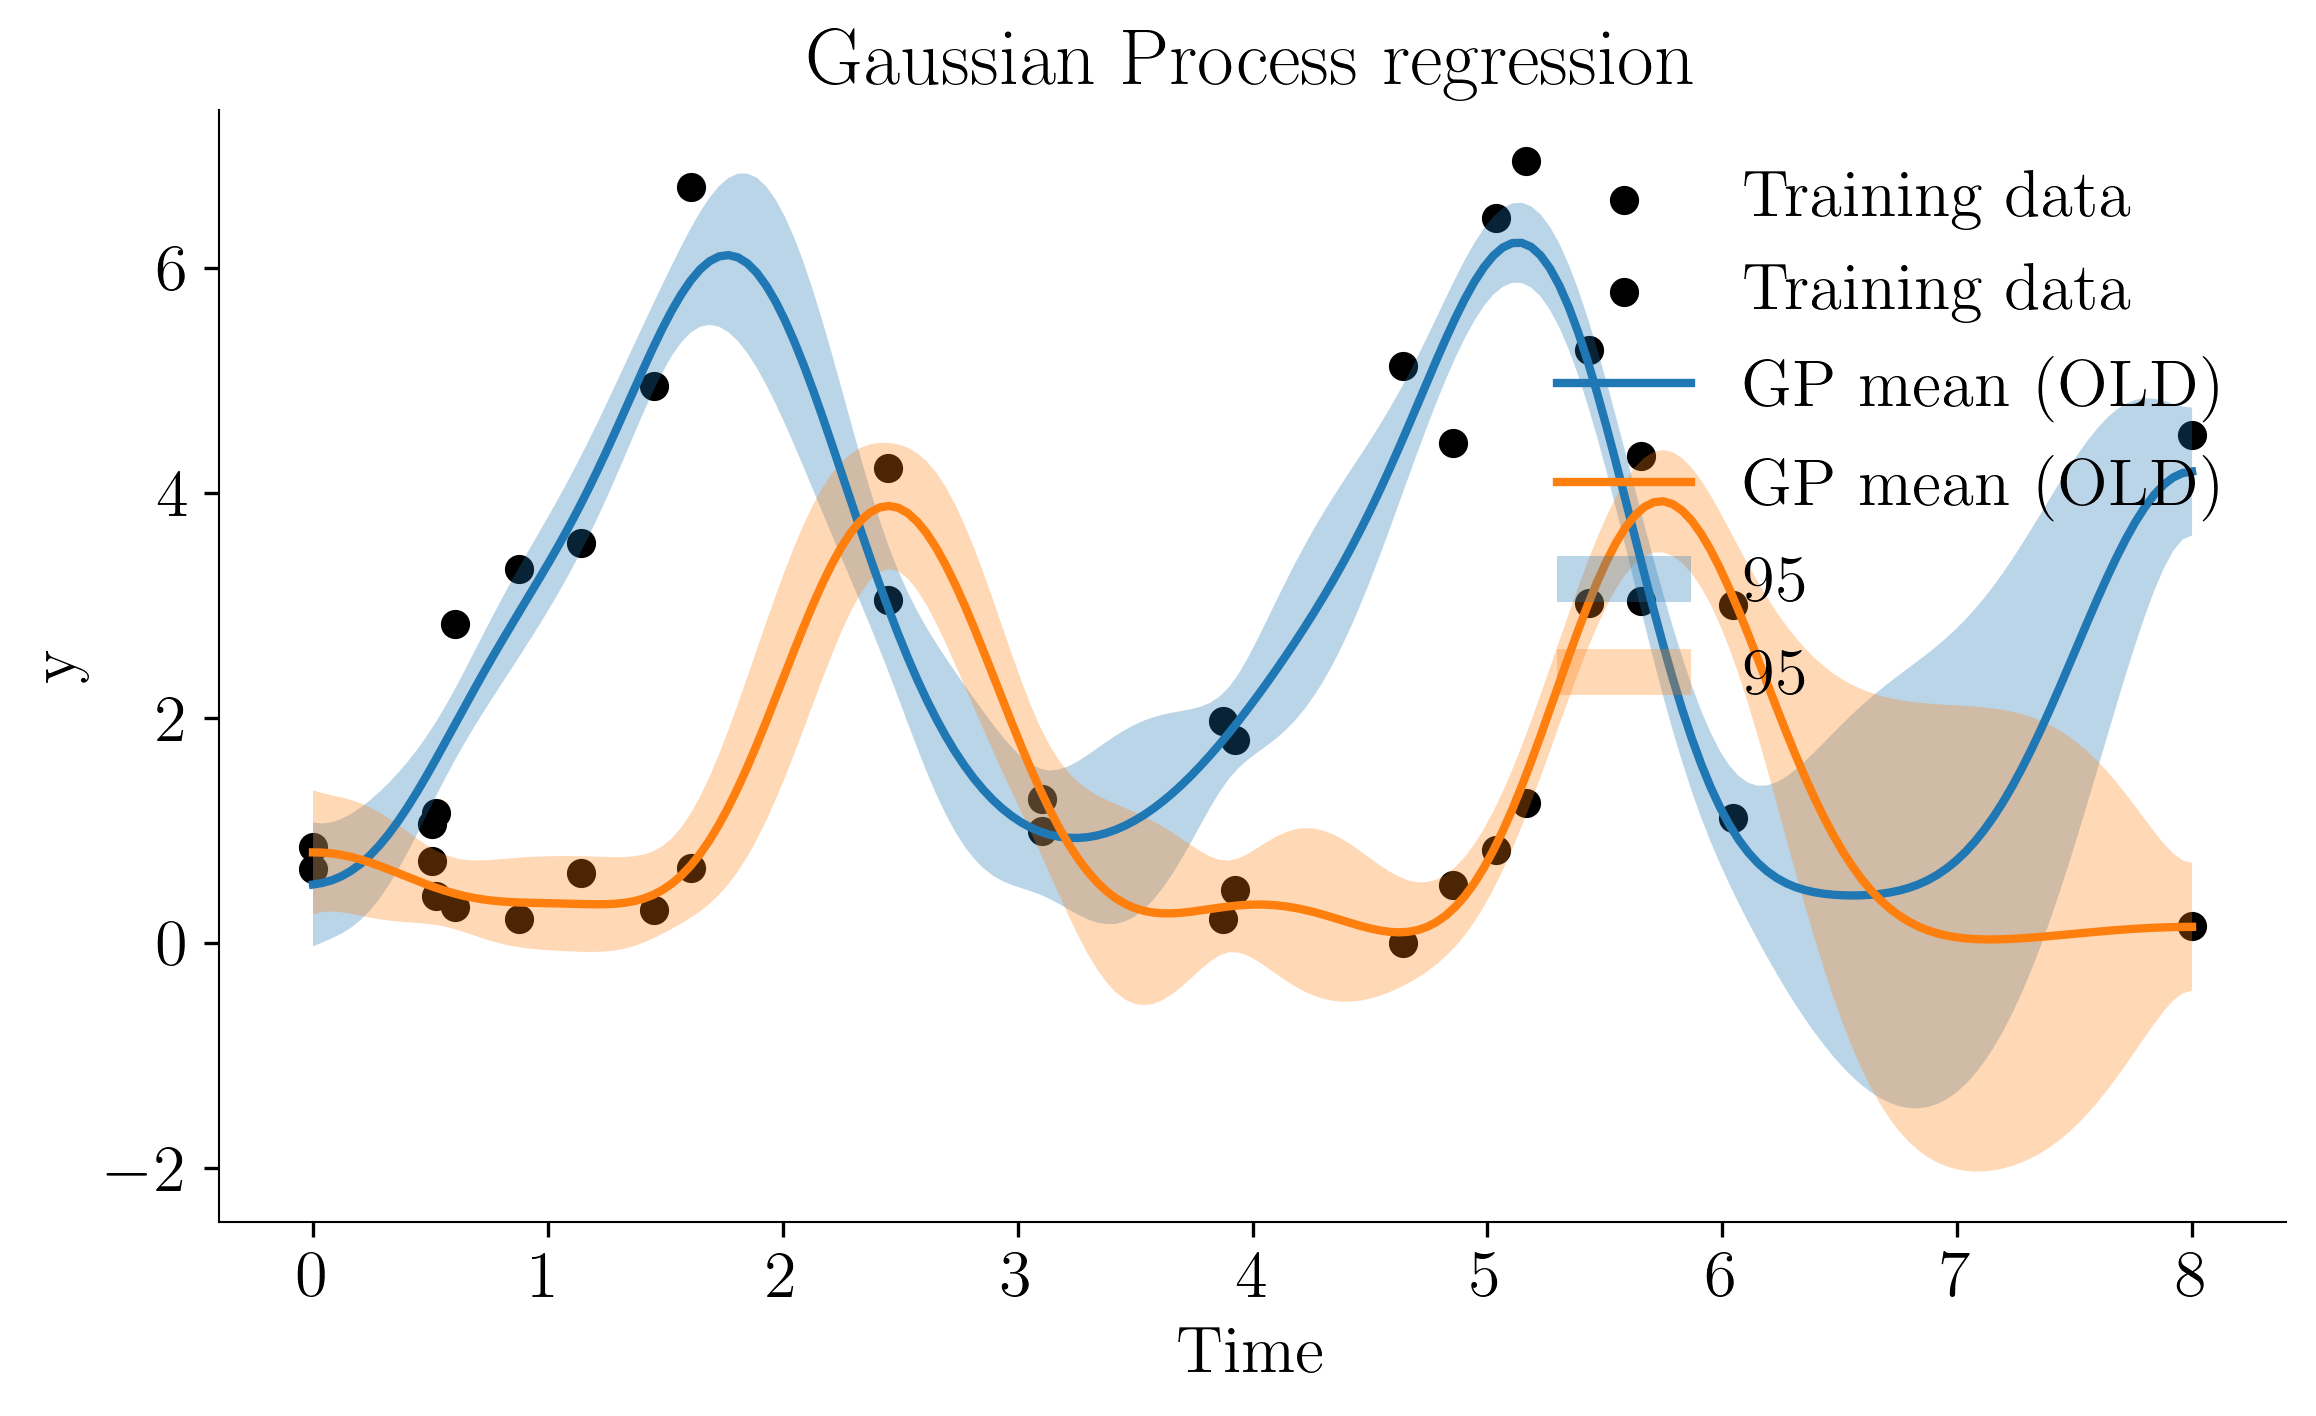

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# 1) training data
plt.scatter(time, y[:,0], color='k', marker='o', label='Training data')
plt.scatter(time, y[:,1], color='k', marker='o', label='Training data')

# 2) posterior mean
plt.plot(t_test, mu, lw=2, label='GP mean (OLD)')

# 3) ±2σ uncertainty band (≈95% CI)
plt.fill_between(
    t_test,
    mu[:,0] - 2*std,
    mu[:,0] + 2*std,
    alpha=0.3,
    label='95% confidence interval'
)
# 3) ±2σ uncertainty band (≈95% CI)
plt.fill_between(
    t_test,
    mu[:,1] - 2*std,
    mu[:,1] + 2*std,
    alpha=0.3,
    label='95% confidence interval'
)

# 4) labels & legend
plt.xlabel('Time')
plt.ylabel('y')
plt.title('Gaussian Process regression')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [34]:
print(time.shape, y.shape)

(20,) (20, 2)


### Run Metropolis Hastings

[1.699     0.5926886] [[0.137509]]
[1.699     0.5926886] [[0.137509]]
()
(40,)
(40,)
initialize with GP posterior
(20,) (20, 20) (1, 1)
(20,)
(20,) (20, 20) (1, 1)
(20,)


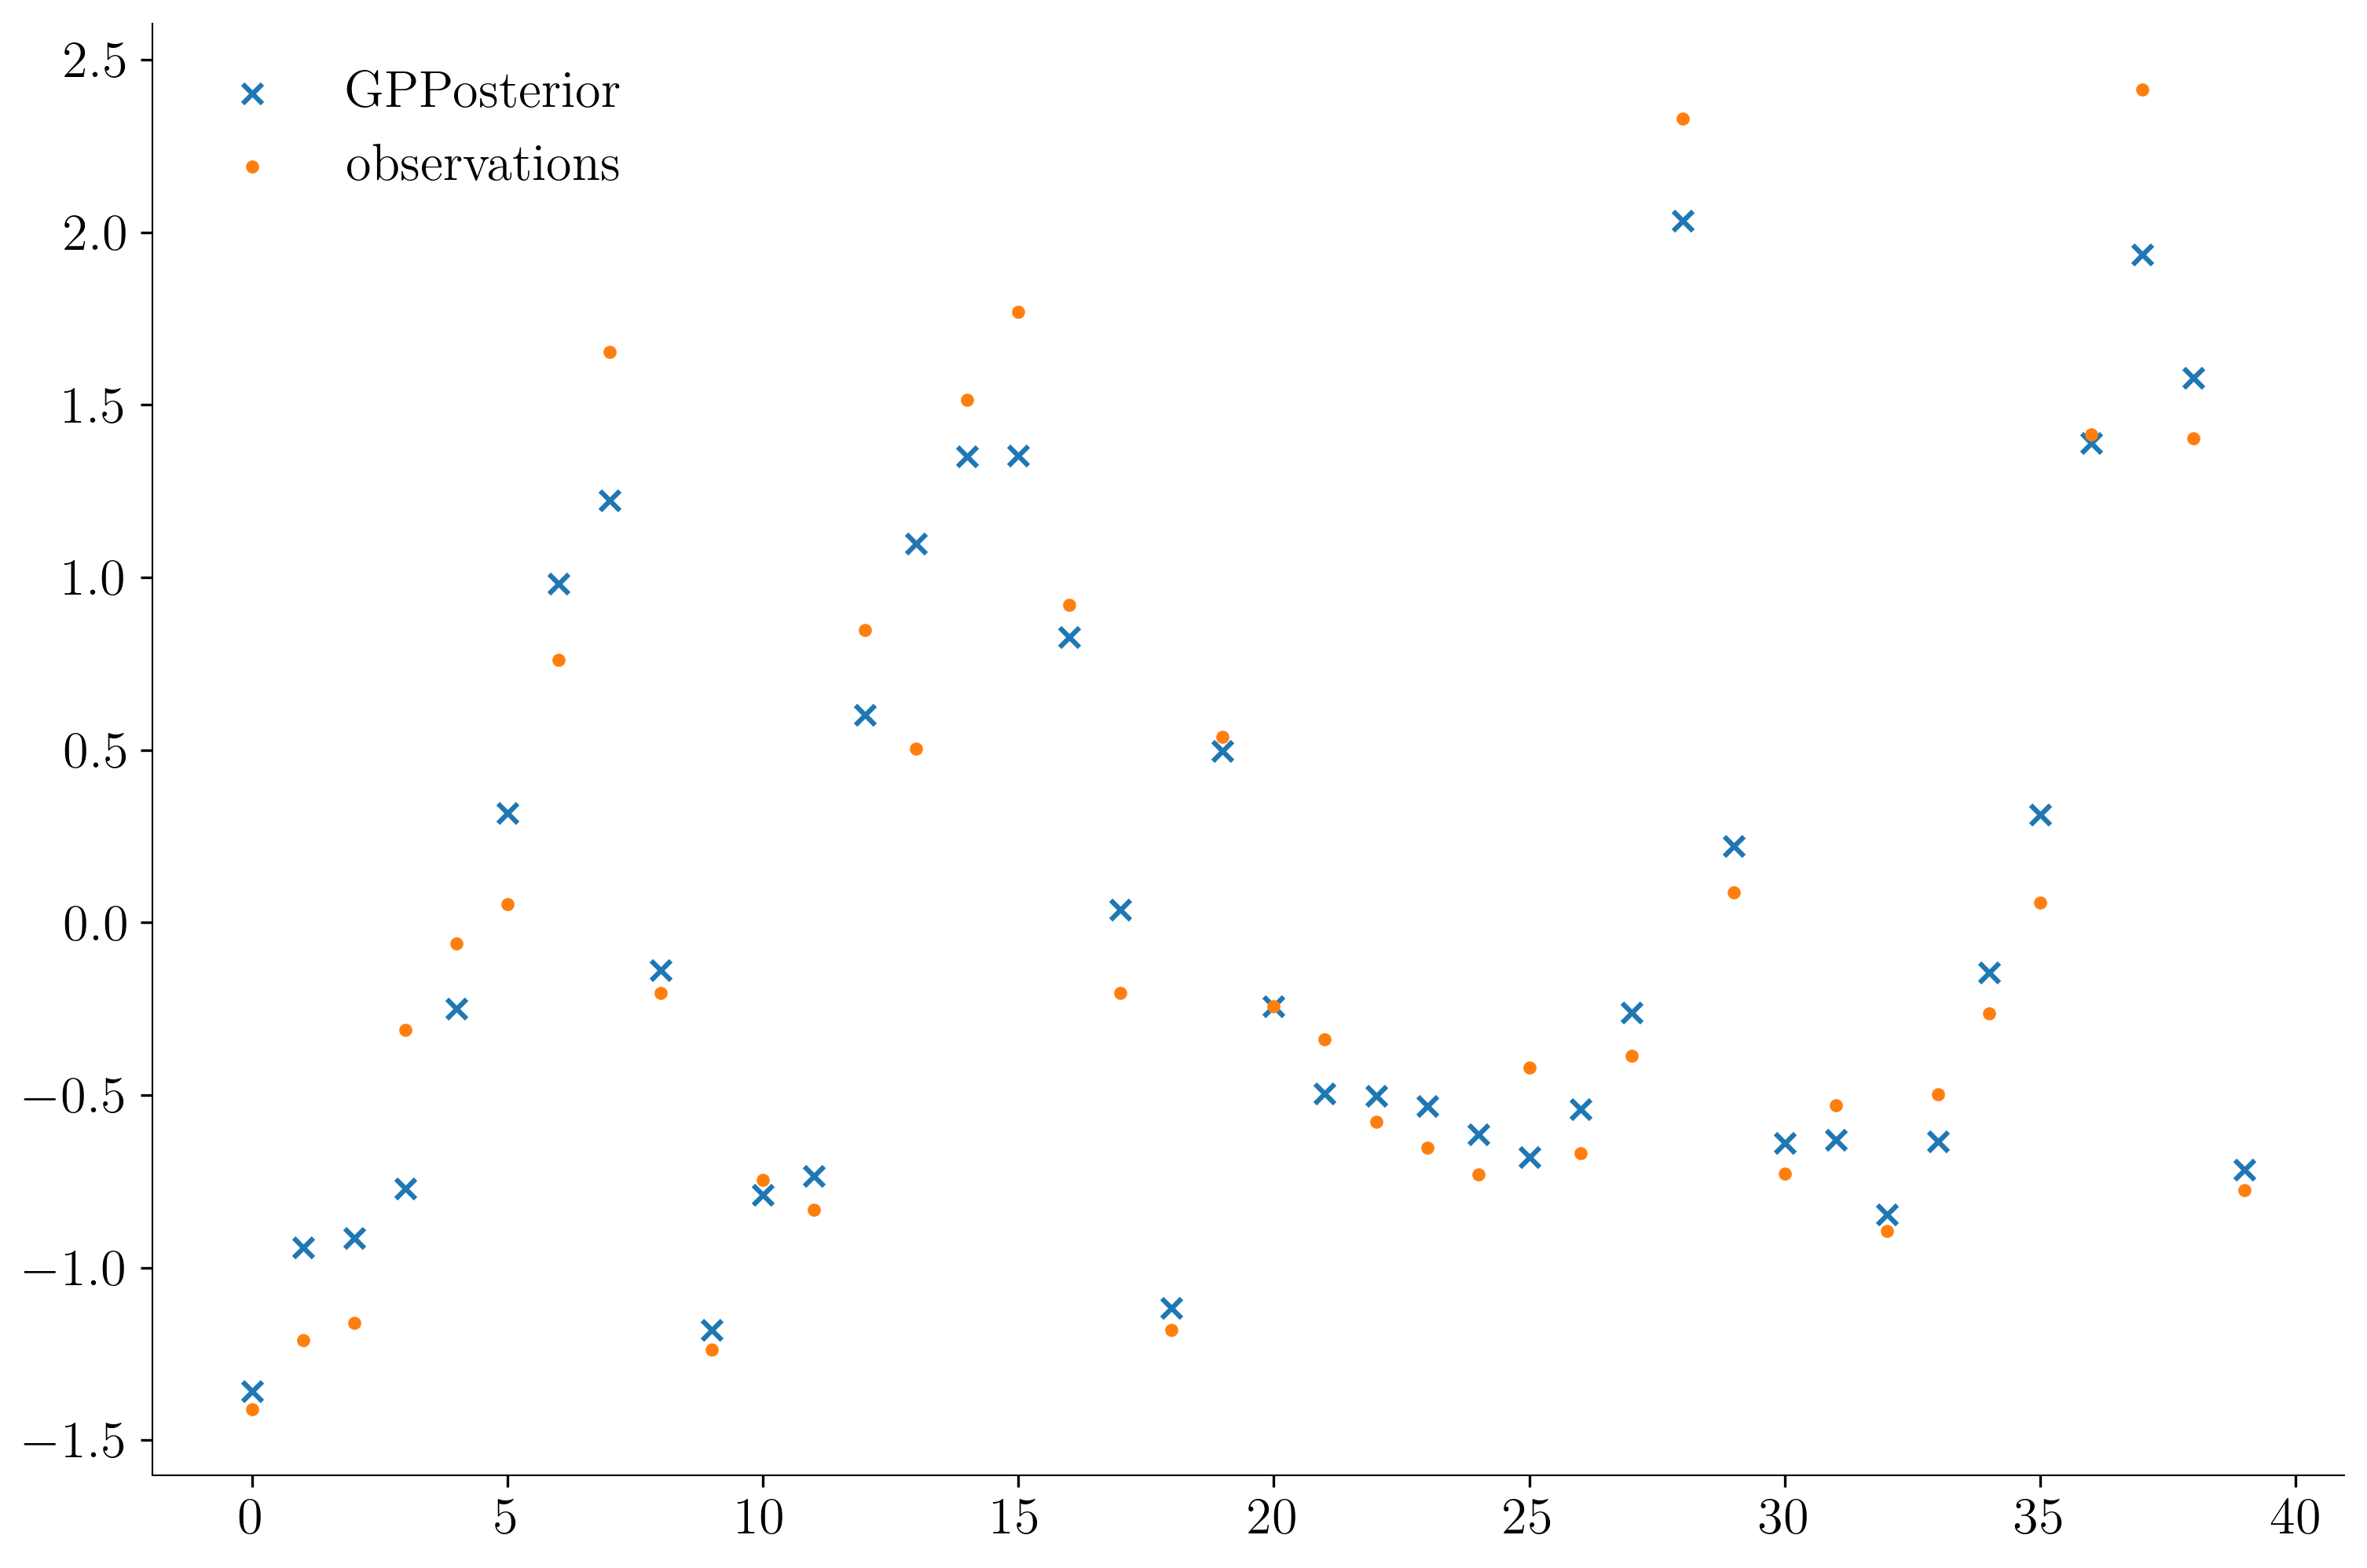

[-3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, -3, 0, 0, 0, 0] [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 100, 100, 100, 100]
0 states needed correction, as they were too close to zero
Starting MCMC 400 400


100%|██████████| 800/800 [00:30<00:00, 26.32it/s]

Done with MCMC

state acceptance mean with std: 
0.42612500000000003 +- 0.21497561634985488

state acceptance range: 
0.19875 to 0.8375

param acceptance mean with std: 
0.540625 +- 0.14364262293971103

param acceptance range: 
0.35125 to 0.71875


In [35]:
# -*- coding: utf-8 -*-
# Author: Philippe Wenk <philippewenk@hotmail.com>
"""
After experiments have been created using the script createExperiments.py,
this script can be run to infer the ODE parameters using FGPGM.
"""
import numpy as np

from LotkaVolterra import LotkaVolterra as exp
from RBF import RBF as kernel
from FGPGM import FGPGM

from matplotlib import pyplot as plt

"""determine standardization"""
standardize=True

# create experiment
experiment = exp()
# load noisy states at observation times
# load hyperparameter
gammas = gammaValues

"""create kernels using hyperparameters calculated by getHyperparams.py"""
kernels = []
for state in np.arange(y.shape[1]):
    currentKernel = kernel(theta=np.abs(np.random.randn(3)),
                           sigma=np.abs(np.random.randn(1)))
    currentKernel.theta = theta
    currentKernel.sigma = sigma
    kernels.append(currentKernel)
  
for kern in kernels:
    print(kern.theta, kern.sigma)


"""find initial values for theta"""
trueTheta = np.array([1.5,1,3,1])
theta0 = np.abs(np.random.randn(trueTheta.size))

gammas = gammaValue*np.ones_like(y.shape[1])
print(gammas.shape)

"""create FGPGM object"""
FM = FGPGM(kernels=kernels,
           time=time,
           y=y,
           experiment=experiment,
           nODEParams=trueTheta.size,
           gamma=gammas,
           normalize=True,
           standardize=standardize)

"""perform actual parameter estimation minimization"""
stateStds = np.ones(y.size)*0.075
paramStds = np.ones(theta0.size)*0.09
propStds = np.concatenate([stateStds, paramStds])

newStates, newParams, param_samples = FM.getFGPGMResults(GPPosteriorInit=True,
                                          blockNegStates=False,
                                          debug=True,
                                          theta0=theta0,
                                          thetaMagnitudes=np.zeros_like(theta0),
                                        #   nSamples=300000,
                                          nSamples=400,
                                          nBurnin=400,
                                          propStds=propStds,
                                          ret_samples=60)

### Plotting

In [36]:
trajectories = []
for i in range(param_samples.shape[0]):
    theta = param_samples[i]
    config.alpha, config.beta, config.delta, config.gamma = theta[0], theta[1], theta[3], theta[2]
    sampler = step1.TrajectorySampler(
        training_span=training_span,
        num_samples=num_samples,
        noiselevel=noiselevel,
        num_regression_points=num_regression_points,
        synced=True,
        integersonly=False,
        config=config,
    )

    (
        truthmodel,
        time_domain_prediction,
        true_states_not,
        time_domains_sampled,
        snapshots_sampled,
    ) = sampler.sample()
    trajectories.append(true_states_not)

# Get mean traj
theta = param_samples[i]
config.alpha, config.beta, config.delta, config.gamma = newParams[0], newParams[1], newParams[3], newParams[2]
sampler = step1.TrajectorySampler(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    synced=True,
    integersonly=False,
    config=config,
)

(
    truthmodel,
    time_domain_prediction,
    true_states_not,
    time_domains_sampled,
    snapshots_sampled,
) = sampler.sample()
time = time_domain_prediction
mean_traj = true_states_not

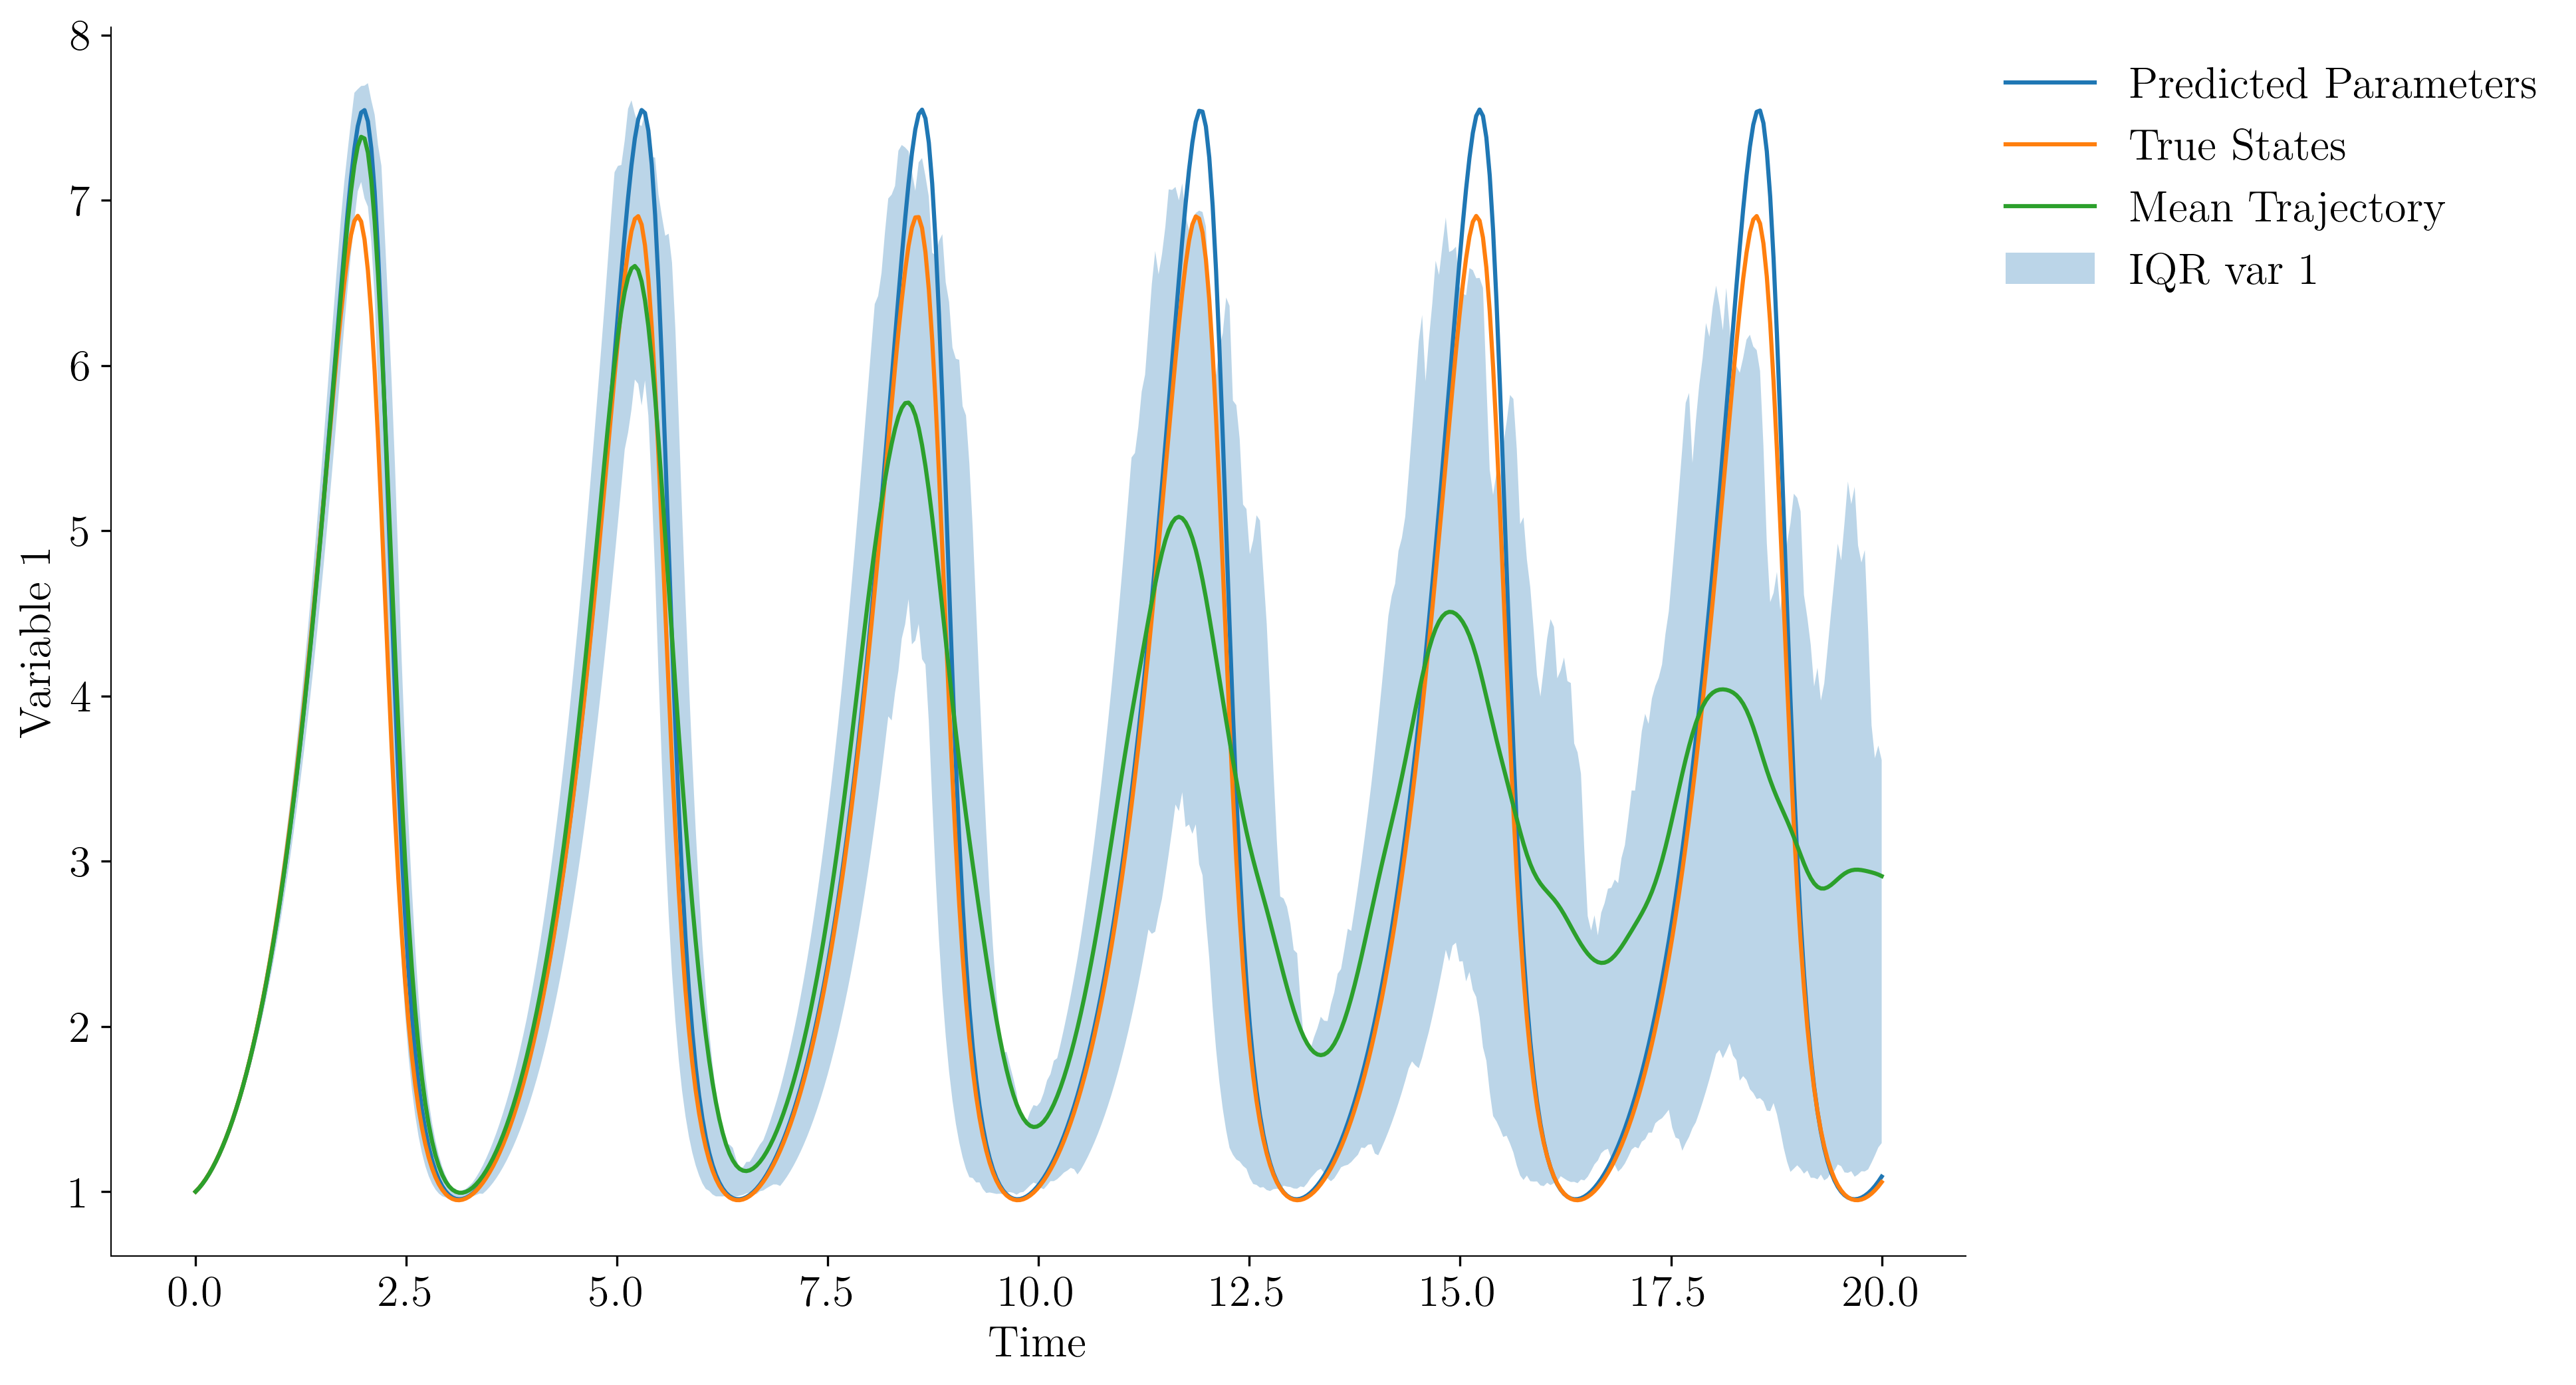

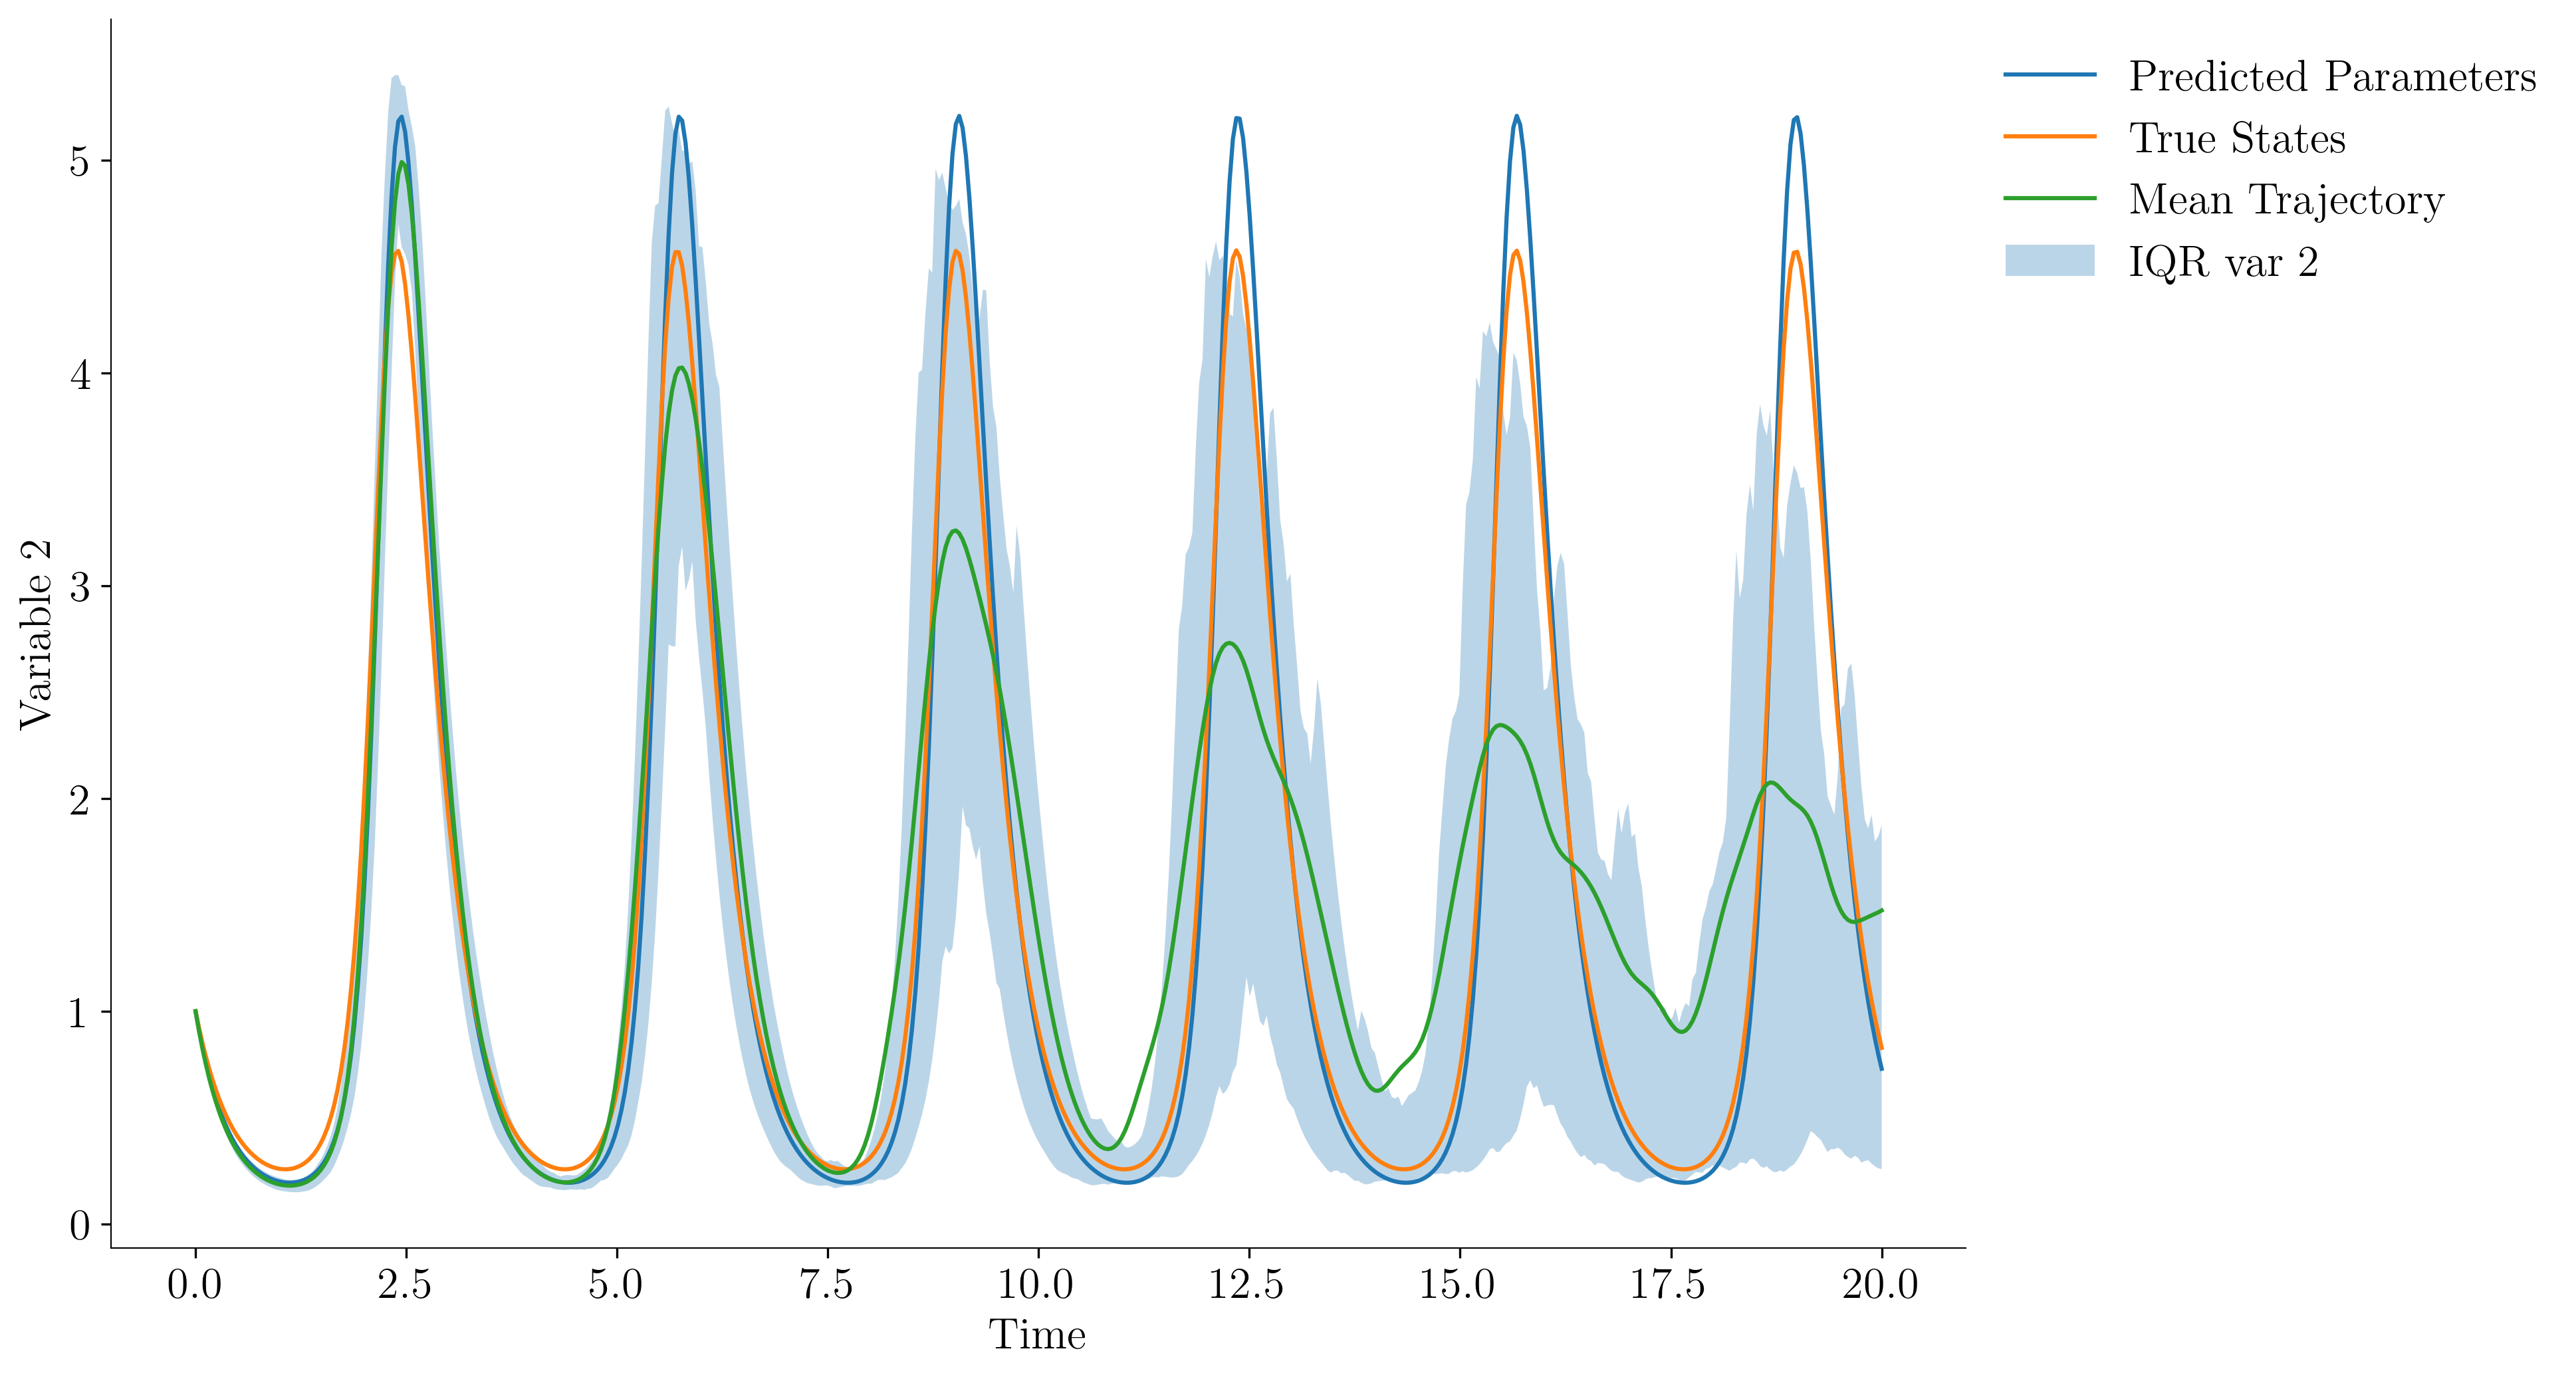

In [37]:
# Compute interquartile ranges
q1 = np.percentile(trajectories, 25, axis=0)
q3 = np.percentile(trajectories, 75, axis=0)
mean_of_traj = np.mean(trajectories, axis=0)

# Plot variable 1
plt.figure()
plt.plot(time, mean_traj[0], label='Predicted Parameters')
plt.plot(time, true_states[0], label='True States')
plt.plot(time, mean_of_traj[0], label='Mean Trajectory')
plt.fill_between(time, q1[0], q3[0], alpha=0.3, label='IQR var 1')
plt.xlabel('Time')
plt.ylabel('Variable 1')
plt.legend()
plt.legend(bbox_to_anchor=(1, 1))

# Plot variable 2
plt.figure()
plt.plot(time, mean_traj[1], label='Predicted Parameters')
plt.plot(time, true_states[1], label='True States')
plt.plot(time, mean_of_traj[1], label='Mean Trajectory')
plt.fill_between(time, q1[1], q3[1], alpha=0.3, label='IQR var 2')
plt.xlabel('Time')
plt.ylabel('Variable 2')
plt.legend(bbox_to_anchor=(1, 1))

plt.show()

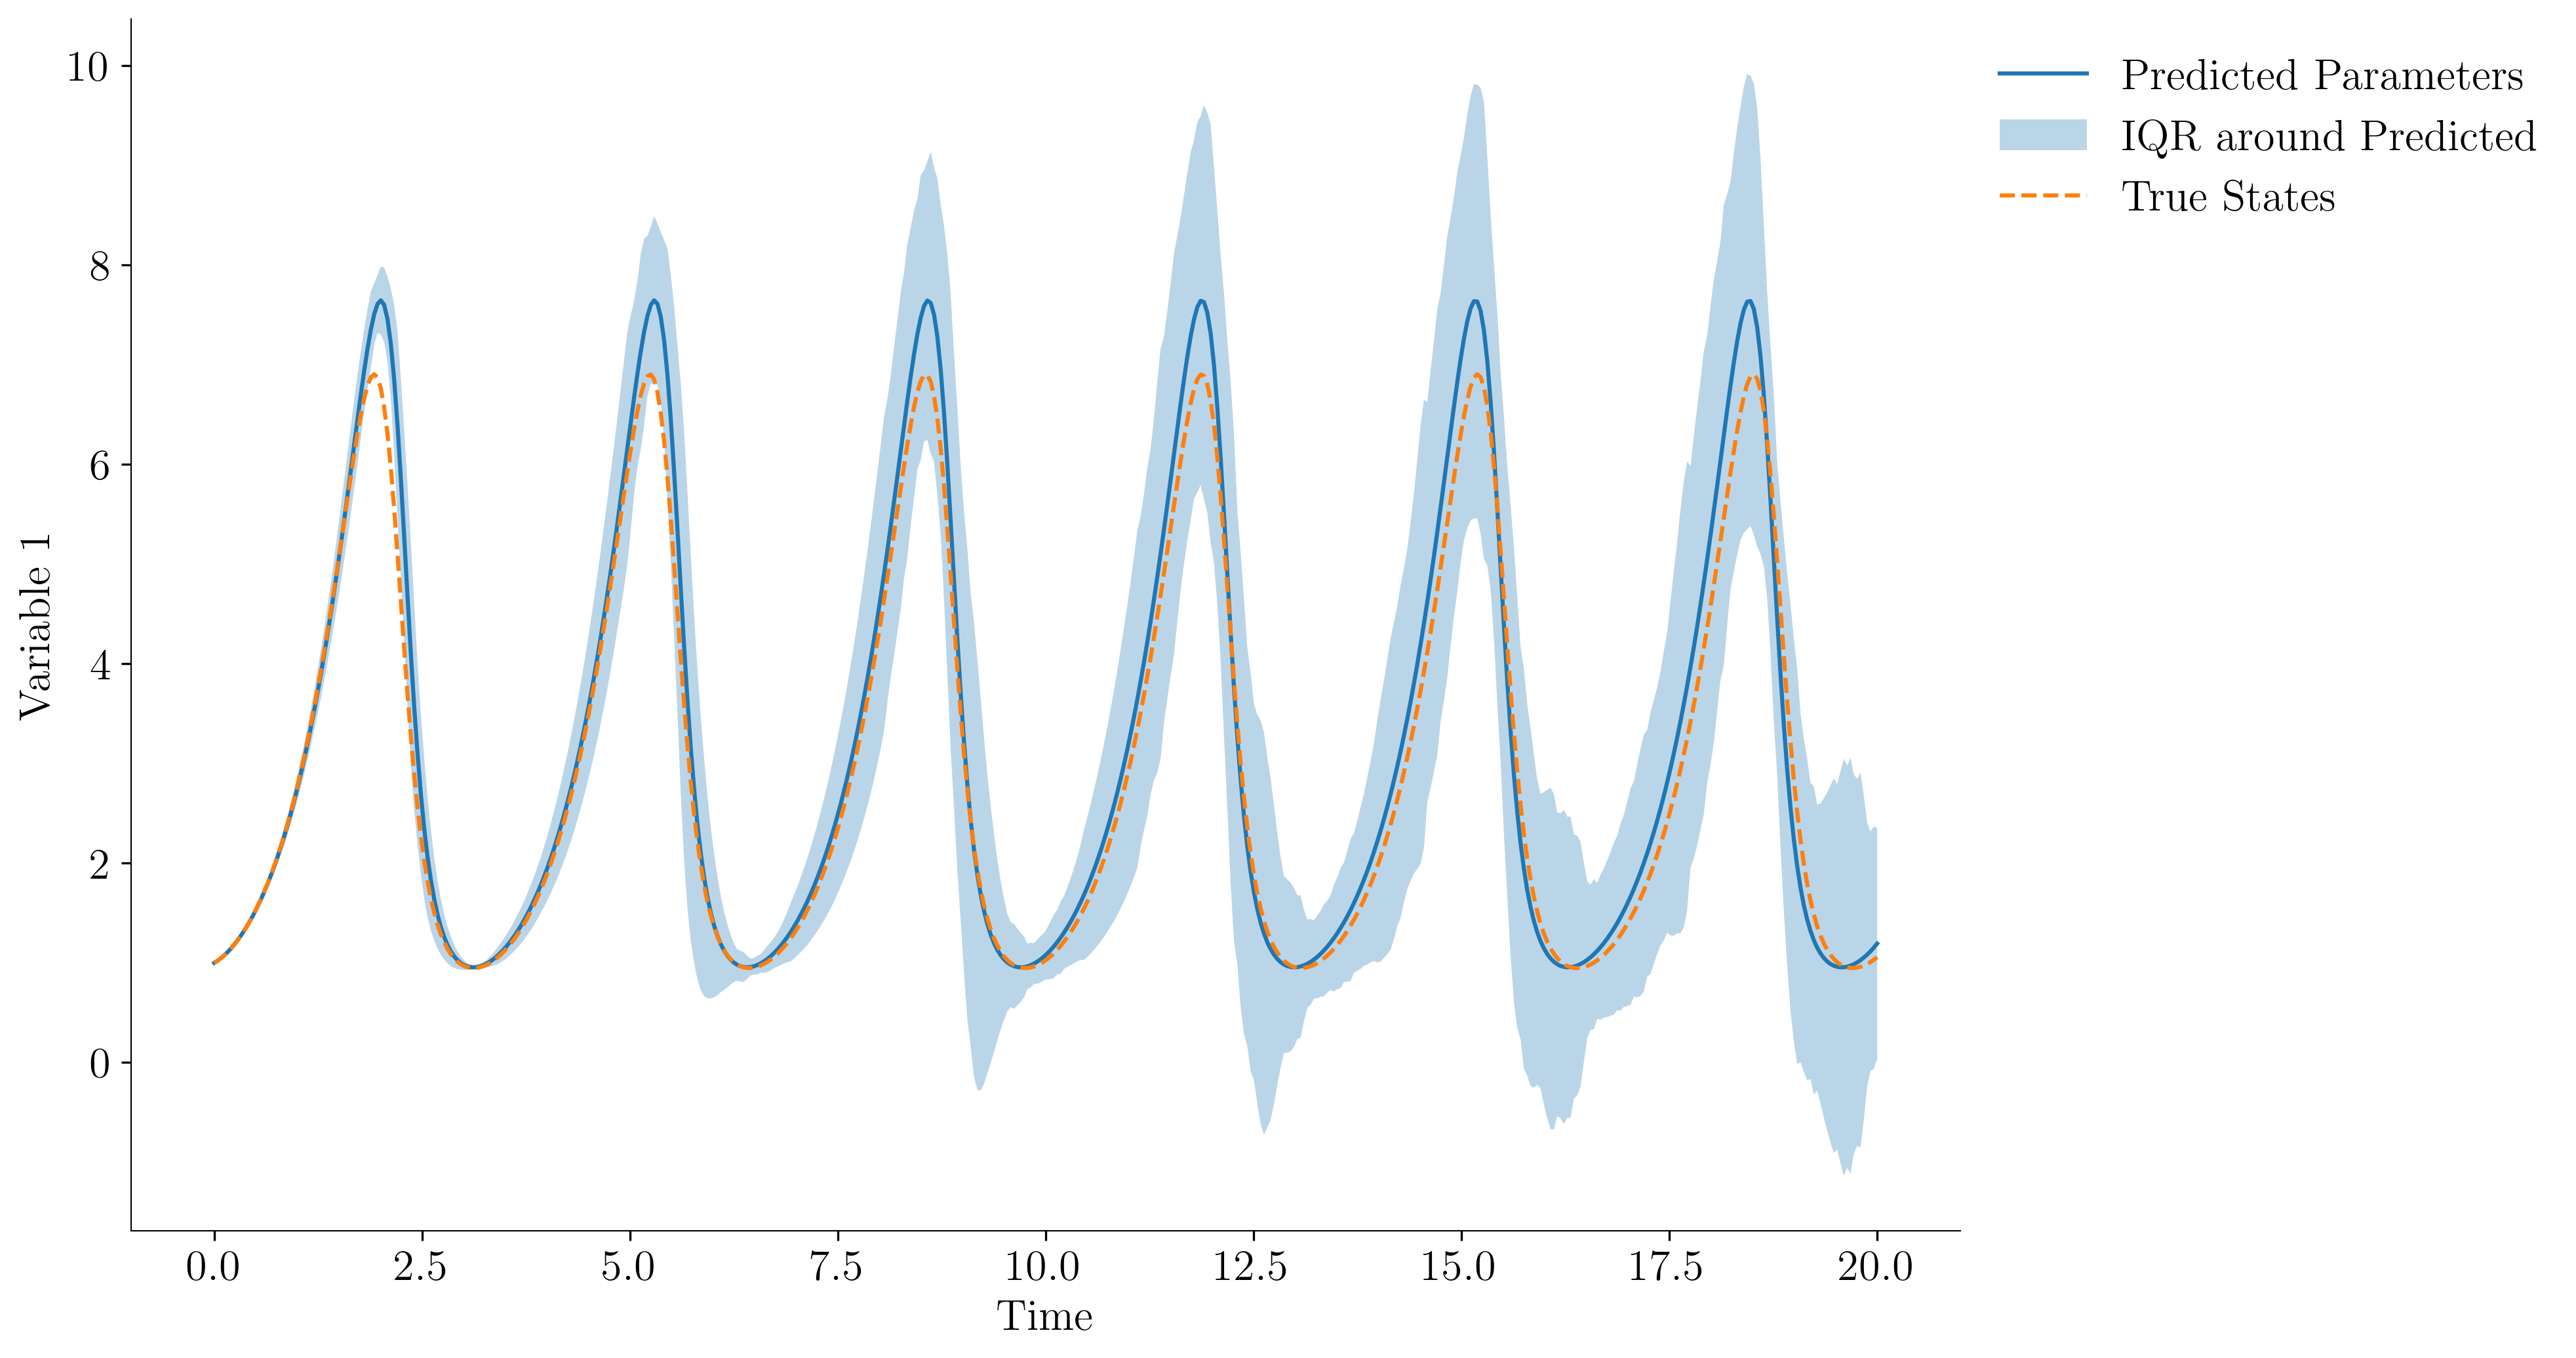

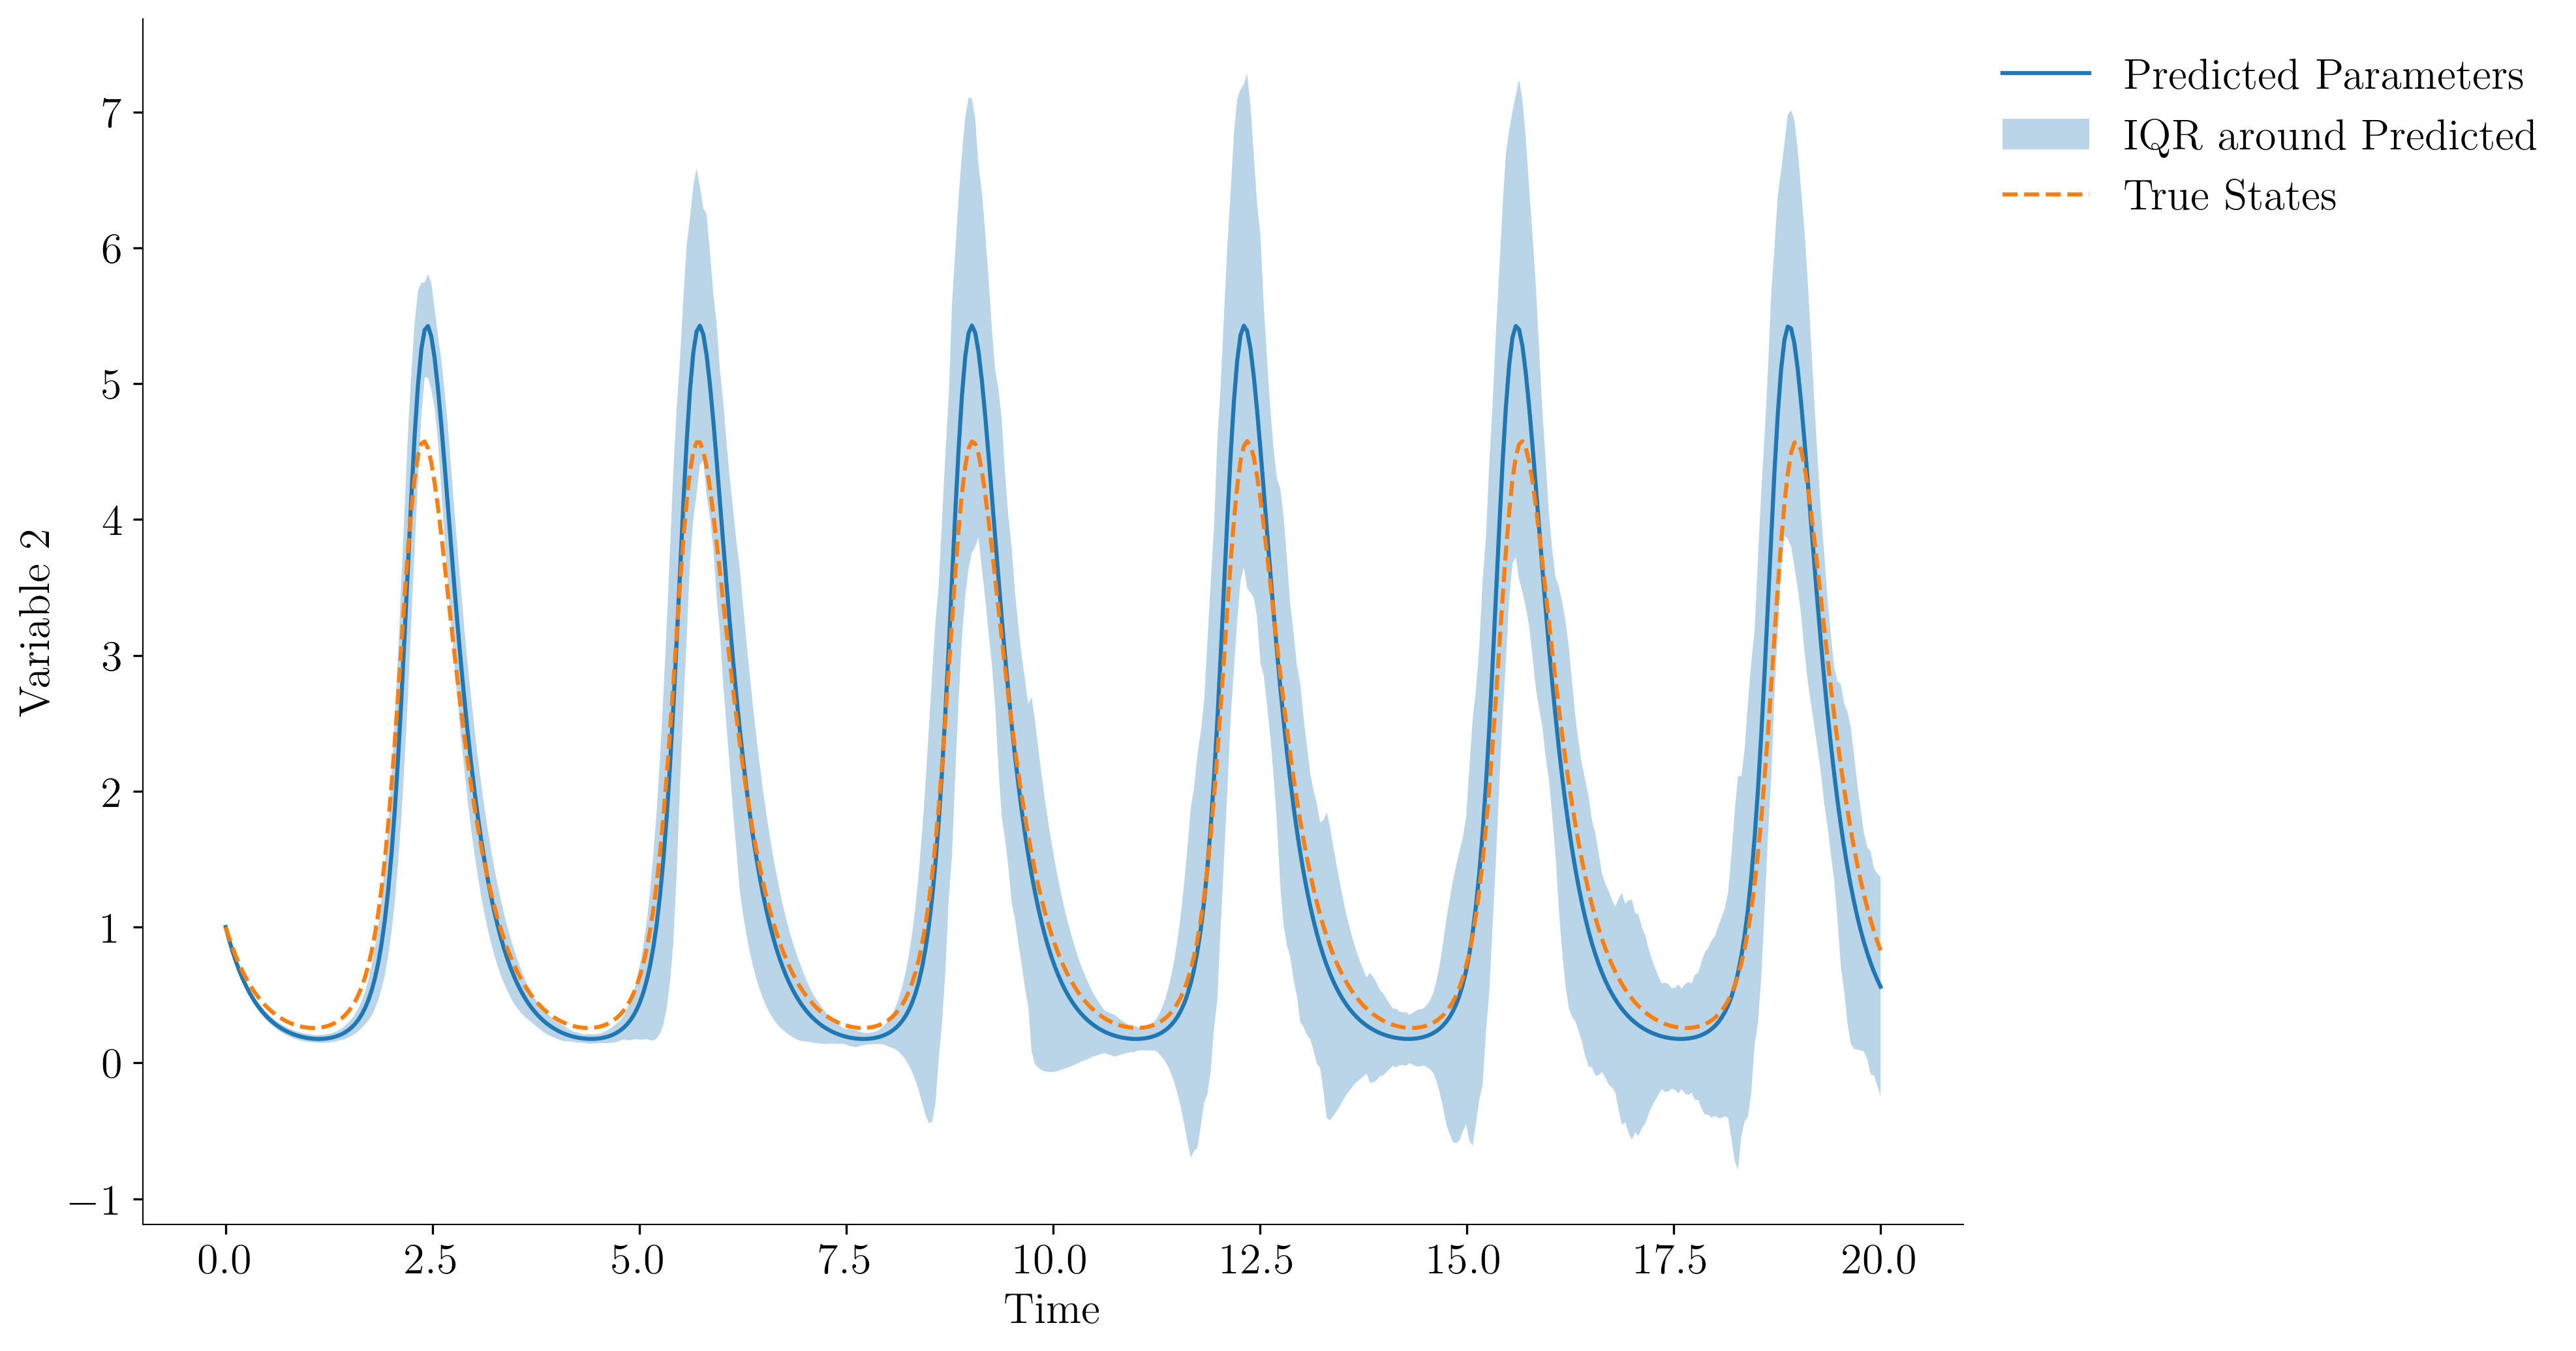

In [38]:
# stack and get IQR
T   = np.stack(trajectories, axis=0)      # (n_samples, n_vars, n_time)
q1  = np.percentile(T, 25, axis=0)        # (n_vars, n_time)
q3  = np.percentile(T, 75, axis=0)

# half the IQR gives the radius of the tube
half_iqr = (q3 - q1) / 2                  # (n_vars, n_time)

# build your Predicted trajectory (at the mean of the params)
mean_params = param_samples.mean(axis=0)
config.alpha, config.beta, config.delta, config.gamma = (
    mean_params[0], mean_params[1],
    mean_params[3], mean_params[2]
)
_, time, pred_traj, *_ = step1.TrajectorySampler(
    training_span, num_samples, noiselevel,
    num_regression_points, synced=True, integersonly=False,
    config=config
).sample()
# pred_traj is (n_vars, n_time)

# now the lower/upper bounds are just pred_traj ± half_iqr
lower = pred_traj - half_iqr
upper = pred_traj + half_iqr

# plotting:
import matplotlib.pyplot as plt
for var_idx in [0,1]:
    plt.figure()
    plt.plot(time, pred_traj[var_idx],   label='Predicted Parameters')
    plt.fill_between(time,
                     lower[var_idx],
                     upper[var_idx],
                     alpha=0.3,
                     label='IQR around Predicted')
    plt.plot(time, true_states[var_idx], '--', label='True States')
    plt.xlabel('Time')
    plt.ylabel(f'Variable {var_idx+1}')
    plt.legend(bbox_to_anchor=(1,1))
plt.show()
